# P1 (ML_F) CUSTOMER CLASSIFICATION

### Importing Modules

In [1]:
# for one of the errors observed while running KNN
# !pip install --upgrade threadpoolctl scikit-learn
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# data manipulation & exploration
import pandas as pd
import numpy as np
import time

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Classification models
from catboost import CatBoostClassifier

# Others
from sklearn.metrics import (classification_report, f1_score, precision_score, recall_score, 
                             accuracy_score, confusion_matrix, make_scorer)
from scipy.sparse import issparse

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

### Timer Start

In [2]:
start_all = time.time()

### Load Data

In [3]:
t0 = time.time()
train = pd.read_csv('existing_base_train.csv')
test = pd.read_csv('existing_base_test.csv')
test_ref = test['REF_NO']
print(f'Data loaded in {round(time.time() - t0, 2)} seconds')

Data loaded in 0.1 seconds


### Feature Additions - From Categorical

In [4]:
def create_features_from_cat(df):
    # children as numeric:
    children_map = {'Zero': 0, '1': 1, '2': 2, '3': 3, '4+': 4}
    df['children_num'] = df['children'].map(children_map)

    # Both self employed
    df['both_se'] = ((df['self_employed'] == 'Yes') & (df['self_employed_partner'] == 'Yes')).astype(int)

    # Estimated Income
    income_map = {'< 4,000': 3000, '< 8,000, >= 4,000': 6000, '<10,000, >= 8,000': 9000, '<12,500, >=10,000': 11250,
                  '<15,000, >=12,500': 13750, '<17,500, >=15,000': 16250, '<20,000, >=17,500': 18750,
                  '<22,500, >=20,000': 21250, '<25,000, >=22,500': 23750, '<27,500, >=25,000': 26250,
                  '<30,000, >=27,500': 28750, '>=35,000': 40000, 'Unknown': 12000}
    df['income_est'] = df['family_income'].map(income_map)
    
    # Family size
    df['partnered_flag'] = df['status'].apply(lambda x: 1 if x == 'Partner' else 0)
    df['family_size'] = 1 + df['children_num'] + df['partnered_flag']
    
    # Income per capita
    df['inc_per_cap'] = df['income_est']/df['family_size']
    
    # Working member count
    non_working_roles = ['Housewife', 'Retired', 'Student', 'Unknown']
    df['working_members'] = ((~df['occupation'].isin(non_working_roles)).astype(int) + 
                            (~df['occupation_partner'].isin(non_working_roles)).astype(int))
    
    # High Risk Income
    df['high_risk'] = ((df['both_se'] == 1) & (df['income_est'] <= 15000)).astype(int)
    
    return df

In [5]:
train = create_features_from_cat(train)
test = create_features_from_cat(test)

In [6]:
train.head()

,REF_NO,children,age_band,status,occupation,occupation_partner,home_status,family_income,self_employed,self_employed_partner,...,Portfolio_Balance,Revenue_Grid,children_num,both_se,income_est,partnered_flag,family_size,inc_per_cap,working_members,high_risk
0,5466,2,31-35,Partner,Professional,Professional,Own Home,">=35,000",No,No,...,360.37,2,2,0,40000,1,4,10000.000000,2,0
1,9091,Zero,45-50,Partner,Secretarial/Admin,Professional,Own Home,">=35,000",No,No,...,89.22,2,0,0,40000,1,2,20000.000000,2,0
2,9744,1,36-40,Partner,Manual Worker,Manual Worker,Rent Privately,"<22,500, >=20,000",Yes,Yes,...,14.50,2,1,1,21250,1,3,7083.333333,2,0
3,10700,2,31-35,Partner,Manual Worker,Manual Worker,Own Home,"<25,000, >=22,500",No,No,...,68.98,2,2,0,23750,1,4,5937.500000,2,0
4,1987,Zero,55-60,Partner,Housewife,Professional,Own Home,">=35,000",No,No,...,1.88,2,0,0,40000,1,2,20000.000000,1,0


### Feature additions - From Numerical

In [7]:
def add_numeric_features(df):
    df['total_inv'] = (df['Investment_in_Mutual_Fund'] + df['Investment_in_Mutual_Fund'] + 
                      df['Investment_in_Commudity'] + df['Investment_in_Equity'] + df['Investment_in_Derivative']) + 1
    df['total_loans'] = df['Home_Loan'] + df['Balance_Transfer'] + df['Personal_Loan']
    df['total_insurance'] = df['Life_Insurance'] + df['Medical_Insurance']
    df['total_spend'] = df['Average_Credit_Card_Transaction'] + df['Online_Purchase_Amount']
    
    df['cc_pct'] = df['Average_Credit_Card_Transaction']/(df['income_est'] + 1e-3)
    df['online_spend_pct'] = df['Online_Purchase_Amount']/(df['income_est'] + 1e-3)
    df['spend_ratio'] = df['total_spend']/(df['income_est'] + 1e-3)
    df['loan_ratio'] = df['total_loans']/(df['income_est'] + 1e-3)
    df['per_loan_ratio'] = df['Personal_Loan']/(df['income_est'] + 1e-3)
    return df

In [8]:
train = add_numeric_features(train)
test = add_numeric_features(test)

In [9]:
train.head()

,REF_NO,children,age_band,status,occupation,occupation_partner,home_status,family_income,self_employed,self_employed_partner,...,high_risk,total_inv,total_loans,total_insurance,total_spend,cc_pct,online_spend_pct,spend_ratio,loan_ratio,per_loan_ratio
0,5466,2,31-35,Partner,Professional,Professional,Own Home,">=35,000",No,No,...,0,639.06,260.86,388.51,34.66,0.000674,0.000192,0.000866,0.006521,4.385750e-03
1,9091,Zero,45-50,Partner,Secretarial/Admin,Professional,Own Home,">=35,000",No,No,...,0,88.42,90.47,110.95,54.97,0.000899,0.000475,0.001374,0.002262,3.997500e-04
2,9744,1,36-40,Partner,Manual Worker,Manual Worker,Rent Privately,"<22,500, >=20,000",Yes,Yes,...,0,37.07,24.48,18.44,0.00,0.000000,0.000000,0.000000,0.001152,9.411764e-07
3,10700,2,31-35,Partner,Manual Worker,Manual Worker,Own Home,"<25,000, >=22,500",No,No,...,0,21.00,0.00,29.99,44.99,0.001894,0.000000,0.001894,0.000000,0.000000e+00
4,1987,Zero,55-60,Partner,Housewife,Professional,Own Home,">=35,000",No,No,...,0,24.28,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000e+00


In [10]:
print(train.describe())

             REF_NO  year_last_moved  Average_Credit_Card_Transaction  \
count   8124.000000      8124.000000                      8124.000000   
mean    5797.343304      1967.876908                        23.251094   
std     3322.497568       182.563785                        51.147496   
min        2.000000         0.000000                         0.000000   
25%     2924.750000      1978.000000                         0.000000   
50%     5811.500000      1988.000000                         0.000000   
75%     8681.500000      1994.000000                        23.480000   
max    11518.000000      1999.000000                       662.260000   

       Balance_Transfer  Term_Deposit  Life_Insurance  Medical_Insurance  \
count       8124.000000   8124.000000     8124.000000        8124.000000   
mean          46.082922     27.284649       65.317939          18.826195   
std           79.084692     54.133537       95.762451          32.022332   
min            0.000000      0.000000 

### Prepare Target

In [11]:
t0 = time.time()
y = train['Revenue_Grid'].map({1: 1, 2: 0}) # 1 = HNI & 0 = LNI
X = train.drop(['Revenue_Grid', 'REF_NO', 'post_code', 'post_area', 'year_last_moved'], axis = 1)
test = test.drop(['REF_NO', 'post_code', 'post_area', 'year_last_moved'], axis = 1)
print(f'Target Separated in {round(time.time() - t0, 2)} seconds')

Target Separated in 0.01 seconds


In [12]:
X.head()

,children,age_band,status,occupation,occupation_partner,home_status,family_income,self_employed,self_employed_partner,TVarea,...,high_risk,total_inv,total_loans,total_insurance,total_spend,cc_pct,online_spend_pct,spend_ratio,loan_ratio,per_loan_ratio
0,2,31-35,Partner,Professional,Professional,Own Home,">=35,000",No,No,Meridian,...,0,639.06,260.86,388.51,34.66,0.000674,0.000192,0.000866,0.006521,4.385750e-03
1,Zero,45-50,Partner,Secretarial/Admin,Professional,Own Home,">=35,000",No,No,Meridian,...,0,88.42,90.47,110.95,54.97,0.000899,0.000475,0.001374,0.002262,3.997500e-04
2,1,36-40,Partner,Manual Worker,Manual Worker,Rent Privately,"<22,500, >=20,000",Yes,Yes,HTV,...,0,37.07,24.48,18.44,0.00,0.000000,0.000000,0.000000,0.001152,9.411764e-07
3,2,31-35,Partner,Manual Worker,Manual Worker,Own Home,"<25,000, >=22,500",No,No,Scottish TV,...,0,21.00,0.00,29.99,44.99,0.001894,0.000000,0.001894,0.000000,0.000000e+00
4,Zero,55-60,Partner,Housewife,Professional,Own Home,">=35,000",No,No,Yorkshire,...,0,24.28,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000e+00


### Feature Engineering

In [13]:
t0 = time.time()

ordinal_features = {'children': ['Zero', '1', '2', '3', '4+'],
                   'age_band' : ['18-21', '22-25', '26-30', '31-35', '36-40', '41-45', '45-50', '51-55', '55-60', '61-65',
                                 '65-70', '71+', 'Unknown'],
                   'family_income' : ['< 4,000', '< 8,000, >= 4,000', '<10,000, >= 8,000', '<12,500, >=10,000',
                                      '<15,000, >=12,500', '<17,500, >=15,000', '<20,000, >=17,500', '<22,500, >=20,000',
                                      '<25,000, >=22,500', '<27,500, >=25,000', '<30,000, >=27,500',
                                      '>=35,000', 'Unknown']}
ordinal_cols = list(ordinal_features.keys())

nominal_cols = ['status', 'occupation', 'occupation_partner', 'home_status', 'self_employed', 'self_employed_partner',
               'TVarea', 'region', 'gender']

num_cols = X.select_dtypes(include = ['float64', 'int64', 'int32']).columns.tolist()

ordinal_encoder = OrdinalEncoder(categories=[ordinal_features[col] for col in ordinal_cols],
                                handle_unknown = 'use_encoded_value', unknown_value = -1,)
onehot_encoder = OneHotEncoder(drop=None, handle_unknown='ignore')
scaler = StandardScaler()

preprocessor = ColumnTransformer([
    ('ordinal', ordinal_encoder, ordinal_cols),
    ('onehot', onehot_encoder, nominal_cols),
    ('scale', scaler, num_cols)
])

X_processed = preprocessor.fit_transform(X)
test_processed = preprocessor.transform(test)

if issparse(X_processed):
    X_processed = X_processed.toarray()
    test_processed = test_processed.toarray()
    
print(f'Preprocessing in {round(time.time() - t0, 2)} seconds')

Preprocessing in 0.05 seconds


In [14]:
# check ordinal encoder values
t0 = time.time()

# Access the fitted OrdinalEncoder inside the ColumnTransformer
fitted_ordinal_encoder = preprocessor.named_transformers_['ordinal']

# accessing ordinal values
for col, cats in zip(ordinal_cols, fitted_ordinal_encoder.categories_):
    print(f'\nFeature: {col}')
    for i, cat in enumerate(cats):
        print(f' {cat} ---> {i}')
        
print(f'\nOrdinal encoding check in {round(time.time() - t0, 2)} seconds')


Feature: children
 Zero ---> 0
 1 ---> 1
 2 ---> 2
 3 ---> 3
 4+ ---> 4

Feature: age_band
 18-21 ---> 0
 22-25 ---> 1
 26-30 ---> 2
 31-35 ---> 3
 36-40 ---> 4
 41-45 ---> 5
 45-50 ---> 6
 51-55 ---> 7
 55-60 ---> 8
 61-65 ---> 9
 65-70 ---> 10
 71+ ---> 11
 Unknown ---> 12

Feature: family_income
 < 4,000 ---> 0
 < 8,000, >= 4,000 ---> 1
 <10,000, >= 8,000 ---> 2
 <12,500, >=10,000 ---> 3
 <15,000, >=12,500 ---> 4
 <17,500, >=15,000 ---> 5
 <20,000, >=17,500 ---> 6
 <22,500, >=20,000 ---> 7
 <25,000, >=22,500 ---> 8
 <27,500, >=25,000 ---> 9
 <30,000, >=27,500 ---> 10
 >=35,000 ---> 11
 Unknown ---> 12

Ordinal encoding check in 0.0 seconds


In [15]:
# check ordinal encoder values
t0 = time.time()

# Access the fitted OneHotEncoder inside the ColumnTransformer
fitted_onehot_encoder = preprocessor.named_transformers_['onehot']

# Accessing one-hot encoded categories
for col, cats in zip(nominal_cols, fitted_onehot_encoder.categories_):
    print(f'\nFeature: {col}')
    for i, cat in enumerate(cats):
        print(f' {cat} ---> Column {i}')
        
print(f'\nNominal encoding check in {round(time.time() - t0, 2)} seconds')


Feature: status
 Divorced/Separated ---> Column 0
 Partner ---> Column 1
 Single/Never Married ---> Column 2
 Unknown ---> Column 3
 Widowed ---> Column 4

Feature: occupation
 Business Manager ---> Column 0
 Housewife ---> Column 1
 Manual Worker ---> Column 2
 Other ---> Column 3
 Professional ---> Column 4
 Retired ---> Column 5
 Secretarial/Admin ---> Column 6
 Student ---> Column 7
 Unknown ---> Column 8

Feature: occupation_partner
 Business Manager ---> Column 0
 Housewife ---> Column 1
 Manual Worker ---> Column 2
 Other ---> Column 3
 Professional ---> Column 4
 Retired ---> Column 5
 Secretarial/Admin ---> Column 6
 Student ---> Column 7
 Unknown ---> Column 8

Feature: home_status
 Live in Parental Hom ---> Column 0
 Own Home ---> Column 1
 Rent Privately ---> Column 2
 Rent from Council/HA ---> Column 3
 Unclassified ---> Column 4

Feature: self_employed
 No ---> Column 0
 Yes ---> Column 1

Feature: self_employed_partner
 No ---> Column 0
 Yes ---> Column 1

Feature: TVar

In [16]:
#X & test processing check

# Get feature names from each transformer
ordinal_feature_names = ordinal_cols  # OrdinalEncoder doesn't change column names
onehot_feature_names = fitted_onehot_encoder.get_feature_names_out(nominal_cols)
scaled_feature_names = num_cols  # StandardScaler also keeps original names

# Combine all feature names
all_feature_names = list(ordinal_feature_names) + list(onehot_feature_names) + list(scaled_feature_names)

# Convert to DataFrame with column names
X_df = pd.DataFrame(X_processed, columns=all_feature_names)
test_df = pd.DataFrame(test_processed, columns=all_feature_names)

In [17]:
# Set display option to show all columns
pd.set_option('display.max_columns', None)

X_df.head(24)

,children,age_band,family_income,status_Divorced/Separated,status_Partner,status_Single/Never Married,status_Unknown,status_Widowed,occupation_Business Manager,occupation_Housewife,occupation_Manual Worker,occupation_Other,occupation_Professional,occupation_Retired,occupation_Secretarial/Admin,occupation_Student,occupation_Unknown,occupation_partner_Business Manager,occupation_partner_Housewife,occupation_partner_Manual Worker,occupation_partner_Other,occupation_partner_Professional,occupation_partner_Retired,occupation_partner_Secretarial/Admin,occupation_partner_Student,occupation_partner_Unknown,home_status_Live in Parental Hom,home_status_Own Home,home_status_Rent Privately,home_status_Rent from Council/HA,home_status_Unclassified,self_employed_No,self_employed_Yes,self_employed_partner_No,self_employed_partner_Yes,TVarea_Anglia,TVarea_Border,TVarea_Carlton,TVarea_Central,TVarea_Grampian,TVarea_Granada,TVarea_HTV,TVarea_Meridian,TVarea_Scottish TV,TVarea_TV South West,TVarea_Tyne Tees,TVarea_Ulster,TVarea_Unknown,TVarea_Yorkshire,region_Channel Islands,region_East Anglia,region_East Midlands,region_Isle of Man,region_North,region_North West,region_Northern Ireland,region_Scotland,region_South East,region_South West,region_Unknown,region_Wales,region_West Midlands,gender_Female,gender_Male,gender_Unknown,Average_Credit_Card_Transaction,Balance_Transfer,Term_Deposit,Life_Insurance,Medical_Insurance,Average_A/C_Balance,Personal_Loan,Investment_in_Mutual_Fund,Investment_Tax_Saving_Bond,Home_Loan,Online_Purchase_Amount,Investment_in_Commudity,Investment_in_Equity,Investment_in_Derivative,Portfolio_Balance,children_num,both_se,income_est,partnered_flag,family_size,inc_per_cap,working_members,high_risk,total_inv,total_loans,total_insurance,total_spend,cc_pct,online_spend_pct,spend_ratio,loan_ratio,per_loan_ratio
0,2.0,3.0,11.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.072909,-0.203502,5.264442,2.448627,2.182793,1.702048,1.762283,1.438028,0.230636,5.130457,-0.124745,2.716998,1.870680,2.646759,2.502534,1.485020,-0.168774,1.415164,0.571475,1.475971,-0.209493,1.082000,-0.057746,2.144789,1.330834,2.823984,-0.069894,-0.172877,-0.175507,-0.225240,0.280515,0.795561
1,0.0,6.0,11.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.248882,0.359094,-0.504056,0.361772,-0.244725,0.367143,-0.110729,-0.647761,-0.477980,-0.444128,-0.002260,0.191354,-0.233495,-0.058276,-0.001232,-0.697577,-0.168774,1.415164,0.571475,-0.360994,1.102655,1.082000,-0.057746,-0.392354,0.104731,0.248712,0.112338,-0.116274,-0.117458,-0.151077,-0.233816,-0.196999
2,1.0,4.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.454617,-0.273432,-0.504056,-0.489553,-0.587945,-0.703655,-0.298336,-0.485369,-0.477980,-0.444128,-0.207918,-0.649193,-0.610436,-0.676592,-0.691187,0.393722,5.925088,-0.230680,0.571475,0.557488,-0.592202,1.082000,-0.057746,-0.628955,-0.370124,-0.609620,-0.380881,-0.342560,-0.214924,-0.351804,-0.367810,-0.296307
3,2.0,3.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.425050,-0.582739,-0.504056,-0.682125,0.348647,-0.703655,-0.298571,-0.647761,-0.477980,-0.444128,-0.207918,-0.498036,-0.664684,-0.672032,-0.188125,1.485020,-0.168774,-0.011234,0.571475,1.4

In [18]:
X_processed

array([[ 2.        ,  3.        , 11.        , ..., -0.2252403 ,
         0.28051468,  0.79556147],
       [ 0.        ,  6.        , 11.        , ..., -0.15107677,
        -0.2338163 , -0.19699891],
       [ 1.        ,  4.        ,  7.        , ..., -0.35180398,
        -0.36780981, -0.29630694],
       ...,
       [ 1.        ,  5.        ,  1.        , ..., -0.35180398,
         1.72964041, -0.29654131],
       [ 0.        ,  9.        ,  0.        , ..., -0.35180398,
         1.88700714, -0.29654131],
       [ 3.        ,  5.        ,  8.        , ...,  0.12759047,
         0.38206191,  0.70894145]])

In [19]:
test_df.head(10)

,children,age_band,family_income,status_Divorced/Separated,status_Partner,status_Single/Never Married,status_Unknown,status_Widowed,occupation_Business Manager,occupation_Housewife,occupation_Manual Worker,occupation_Other,occupation_Professional,occupation_Retired,occupation_Secretarial/Admin,occupation_Student,occupation_Unknown,occupation_partner_Business Manager,occupation_partner_Housewife,occupation_partner_Manual Worker,occupation_partner_Other,occupation_partner_Professional,occupation_partner_Retired,occupation_partner_Secretarial/Admin,occupation_partner_Student,occupation_partner_Unknown,home_status_Live in Parental Hom,home_status_Own Home,home_status_Rent Privately,home_status_Rent from Council/HA,home_status_Unclassified,self_employed_No,self_employed_Yes,self_employed_partner_No,self_employed_partner_Yes,TVarea_Anglia,TVarea_Border,TVarea_Carlton,TVarea_Central,TVarea_Grampian,TVarea_Granada,TVarea_HTV,TVarea_Meridian,TVarea_Scottish TV,TVarea_TV South West,TVarea_Tyne Tees,TVarea_Ulster,TVarea_Unknown,TVarea_Yorkshire,region_Channel Islands,region_East Anglia,region_East Midlands,region_Isle of Man,region_North,region_North West,region_Northern Ireland,region_Scotland,region_South East,region_South West,region_Unknown,region_Wales,region_West Midlands,gender_Female,gender_Male,gender_Unknown,Average_Credit_Card_Transaction,Balance_Transfer,Term_Deposit,Life_Insurance,Medical_Insurance,Average_A/C_Balance,Personal_Loan,Investment_in_Mutual_Fund,Investment_Tax_Saving_Bond,Home_Loan,Online_Purchase_Amount,Investment_in_Commudity,Investment_in_Equity,Investment_in_Derivative,Portfolio_Balance,children_num,both_se,income_est,partnered_flag,family_size,inc_per_cap,working_members,high_risk,total_inv,total_loans,total_insurance,total_spend,cc_pct,online_spend_pct,spend_ratio,loan_ratio,per_loan_ratio
0,0.0,11.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.366197,0.118704,-0.042391,-0.369039,0.972937,0.279180,-0.298571,0.065925,-0.477980,-0.444128,-0.207918,0.101884,-0.197537,-0.079301,-0.058205,-0.697577,-0.168774,-1.108464,0.571475,-0.360994,-0.783557,-1.354636,-0.057746,0.015283,-0.147124,-0.038821,-0.004215,0.596181,-0.214924,0.193239,0.088434,-0.296541
1,0.0,3.0,11.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.454617,-0.582739,-0.504056,0.361250,0.518227,-0.051894,1.702136,1.430732,1.688112,0.910303,0.414364,-0.213851,1.567515,1.297154,1.347561,-0.697577,-0.168774,1.415164,0.571475,-0.360994,1.102655,-0.136318,-0.057746,1.276344,0.776177,0.474915,0.134680,-0.342560,0.079989,-0.141984,0.047845,0.763688
2,0.0,11.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.454617,1.370603,-0.504056,0.022474,-0.587945,1.237483,-0.298571,1.027081,-0.477980,-0.444128,-0.207918,0.193944,0.346486,0.312308,0.083351,-0.697577,-0.168774,-0.889018,0.571475,-0.360994,-0.619539,-1.354636,-0.057746,0.755913,0.565266,-0.154707,-0.380881,-0.342560,-0.214924,-0.351804,0.849534,-0.296541
3,1.0,1.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.083511,0.188380,-0.504056,-0.494253,-0.275956,-0.703655,0.904720,0.050245,-0.477980,-0.444128,-0.207918,-0.342876,0.096948,-0.058276,-0.028010,0.393722,-0.168774,-0.669572,0.571475,0.55748

In [20]:
test_processed

array([[ 0.        , 11.        ,  3.        , ...,  0.19323855,
         0.08843415, -0.29654131],
       [ 0.        ,  3.        , 11.        , ..., -0.14198434,
         0.04784473,  0.76368798],
       [ 0.        , 11.        ,  4.        , ..., -0.35180398,
         0.84953351, -0.29654131],
       ...,
       [ 0.        ,  6.        ,  8.        , ..., -0.05709478,
        -0.13344312, -0.29654131],
       [ 0.        , 12.        , 12.        , ..., 16.77957051,
        -0.50690465, -0.29654131],
       [ 1.        ,  7.        ,  8.        , ..., -0.30266528,
        -0.26582725,  0.20064318]])

### Validation Split

In [21]:
t0 = time.time()
X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, stratify = y, random_state = 42)
print(f'Validation Split in {round(time.time() - t0, 2)} seconds')

Validation Split in 0.01 seconds


### Hyperparameter Tuning

In [22]:
t0 = time.time()

param_grid = {'iterations': [300, 500, 700], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'depth': [4, 6, 8, 10],
              'l2_leaf_reg': [1, 3, 5, 7, 9], 'border_count': [32, 64, 128], 'bagging_temperature': [0.1, 0.5, 1.0],
              'scale_pos_weight': [1, 1.5, 2]}

catboost_model = CatBoostClassifier(verbose=0, random_seed=42, eval_metric='F1')
f1_scorer = make_scorer(f1_score)
cv = StratifiedKFold(n_splits=5, shuffle=True,random_state=42)

random_search = RandomizedSearchCV(estimator=catboost_model, param_distributions=param_grid, n_iter=25, scoring=f1_scorer,
                                  n_jobs=-1, cv=cv, verbose=2, random_state=42)
random_search.fit(X_train, y_train)
print('Starting RandomizedSearchCV...')
print(f'Hyperparameter tuning in {round(time.time() - t0, 2)} seconds')

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Starting RandomizedSearchCV...
Hyperparameter tuning in 896.6 seconds


### Evaluate Model

In [23]:
best_catboost = random_search.best_estimator_
t0 = time.time()
val_preds = best_catboost.predict(X_val)

acc = accuracy_score(y_val, val_preds)
precision = precision_score(y_val, val_preds)
recall = recall_score(y_val, val_preds)
f1 = f1_score(y_val, val_preds)
f1_macro = f1_score(y_val, val_preds, average = 'macro')
print(f"Classification report: \n{classification_report(y_val, val_preds, target_names=['LNI', 'HNI'])}")
print(f'\nMetrics:')
print(f'- Accuracy: {round(acc, 4)}')
print(f'- Precision: {round(precision, 4)}')
print(f'- Recall: {round(recall, 4)}')
print(f'- F1 Score: {round(f1, 4)}')
print(f'- F1 Macro: {round(f1_macro, 4)}')
print(f'Validation done in {round(time.time() - t0, 2)} seconds')

Classification report: 
              precision    recall  f1-score   support

         LNI       0.98      0.99      0.98      1453
         HNI       0.88      0.86      0.87       172

    accuracy                           0.97      1625
   macro avg       0.93      0.92      0.93      1625
weighted avg       0.97      0.97      0.97      1625


Metrics:
- Accuracy: 0.9729
- Precision: 0.881
- Recall: 0.8605
- F1 Score: 0.8706
- F1 Macro: 0.9277
Validation done in 0.07 seconds


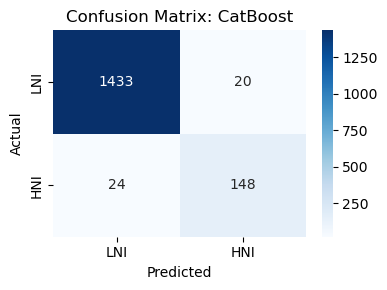

In [24]:
# confusion matrix
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['LNI', 'HNI'], yticklabels=['LNI', 'HNI'])
plt.title(f'Confusion Matrix: CatBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f'confusion_matrix_xgboost.png')
plt.show()
plt.close()

### Threshold Tuning

In [33]:
# Get predicted probabilities for the positive class (HNI)
y_probs = best_catboost.predict_proba(X_val)[:, 1]

# Define a range of thresholds to test
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

# Evaluate F1 score for each threshold
for t in thresholds:
    preds = (y_probs > t).astype(int)
    f1_scores.append(f1_score(y_val, preds))
    
# Find the best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'Best Threshold: {round(best_threshold, 3)}')
print(f'Best F1 Score: {round(best_f1, 4)}')

Best Threshold: 0.54
Best F1 Score: 0.875


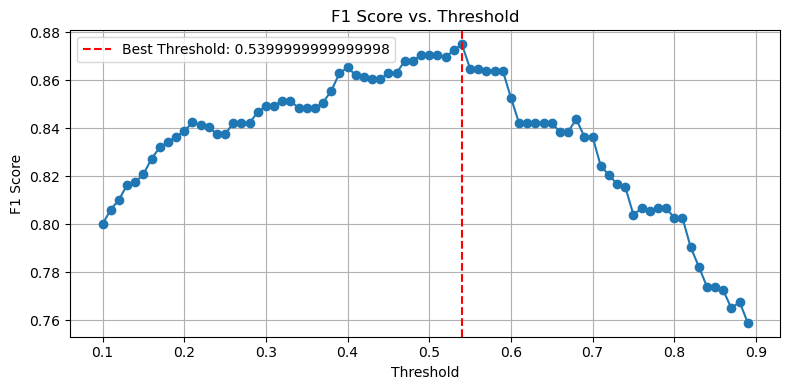

In [34]:
# Plot F1 score vs. threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Threshold: {best_threshold}')
plt.title('F1 Score vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('f1_vs_threshold.png')
plt.show()

### Predict on Test & Submit

In [36]:
test_probs = best_catboost.predict_proba(test_processed)[:, 1]
test_preds = (test_probs > best_threshold).astype(int)
test_preds_final = pd.Series(test_preds).map({1: 1, 0:2}) # Reverse mapping for submission
    
submission = pd.DataFrame({'REF_NO': test_ref, 'Revenue_Grid': test_preds_final})  
submission.to_csv(f'submission_catboosthpt+th.csv', index = False)
print(f'Submission saved as submission_catboosthpt+th.csv in {round(time.time() - t0, 2)} seconds')

Submission saved as submission_catboosthpt+th.csv in 275.6 seconds


### SHAP check

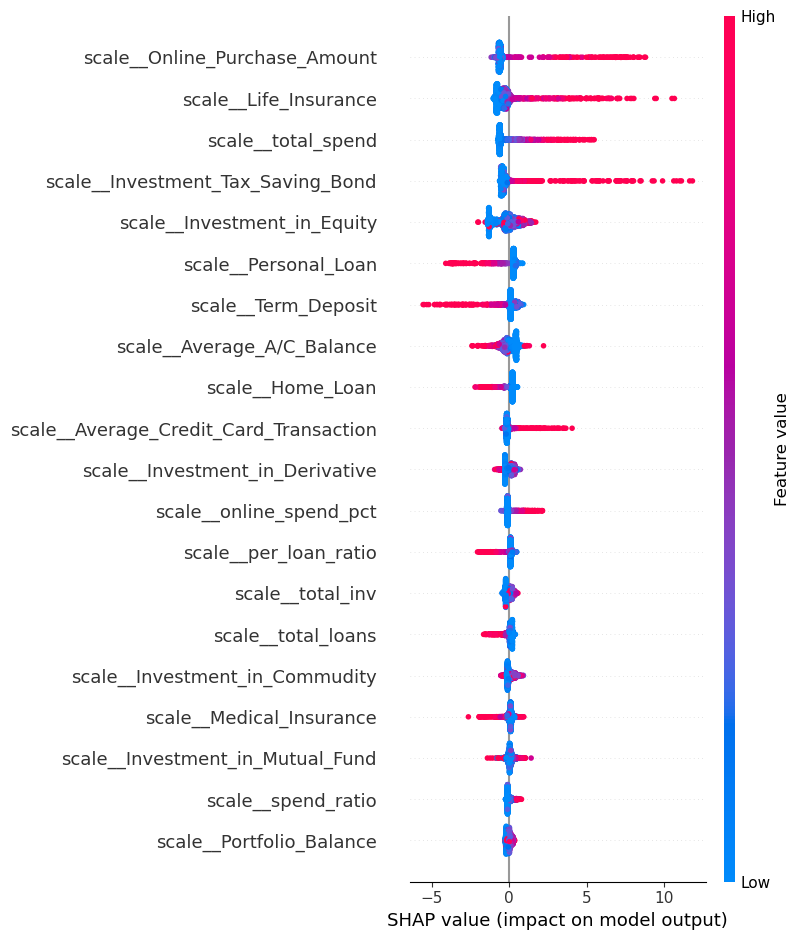

In [26]:
!pip install shap
import shap


feature_names = preprocessor.get_feature_names_out().tolist()
# Initialize SHAP explainer
explainer = shap.TreeExplainer(best_catboost)
shap_values = explainer.shap_values(X_val)

# Summary plot
shap.summary_plot(shap_values, X_val, feature_names=feature_names)

In [27]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[500], feature_names=feature_names)